# 5.1 a tidy forecasting workflow

In [152]:
import pandas as pd

# gdp_df = pd.read_csv("../data/tsibbledata/global_economy.csv")


gdp_df = (
    pd.read_csv("../data/tsibbledata/global_economy.csv")
    .assign(
        unique_id=lambda x: x["Country"],
        ds=lambda x: pd.to_datetime(x["Year"], format="%Y")
    )
    [["unique_id", "ds", "GDP", "Population"]]
    .assign(
        GDP=lambda x: x["GDP"].interpolate(),
        Population=lambda x: x["Population"].interpolate(),
        y=lambda x: x["GDP"] / x["Population"]
    )
)
gdp_df

,unique_id,ds,GDP,Population,y
0,Afghanistan,1960-01-01,5.377778e+08,8996351.0,59.777327
1,Afghanistan,1961-01-01,5.488889e+08,9166764.0,59.878153
2,Afghanistan,1962-01-01,5.466667e+08,9345868.0,58.492874
3,Afghanistan,1963-01-01,7.511112e+08,9533954.0,78.782758
4,Afghanistan,1964-01-01,8.000000e+08,9731361.0,82.208444
...,...,...,...,...,...
15145,Zimbabwe,2013-01-01,1.909102e+10,15054506.0,1268.126633
15146,Zimbabwe,2014-01-01,1.949552e+10,15411675.0,1264.983826
15147,Zimbabwe,2015-01-01,1.996312e+10,15777451.0,1265.294413
15148,Zimbabwe,2016-01-01,2.054868e+10,16150362.0,1272.335450


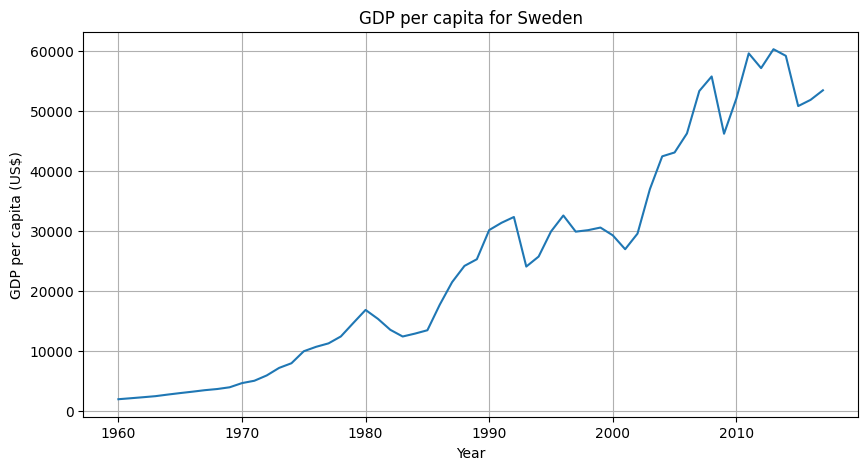

In [153]:
import matplotlib.pyplot as plt

sweden = gdp_df[gdp_df["unique_id"] == "Sweden"]

plt.figure(figsize=(10, 5))
plt.plot(sweden["ds"], sweden["y"])
plt.title("GDP per capita for Sweden")
plt.xlabel("Year")
plt.ylabel("GDP per capita (US$)")
plt.grid(True)
plt.show()

In [154]:
from utilsforecast.feature_engineering import pipeline, trend
from statsforecast import StatsForecast
from statsforecast.models import SklearnModel
from sklearn.linear_model import LinearRegression

sweden_df = (
    gdp_df.loc[lambda x: x["unique_id"] == "Sweden"]
    [["unique_id", "ds", "y"]]
)

train_features, valid_features = pipeline(
    sweden_df, features=[trend], freq="YS", h=3)

trend_model = SklearnModel(LinearRegression())

sf = StatsForecast(models=[trend_model], freq="YS")
sf.fit(df=train_features)

StatsForecast(models=[LinearRegression])

In [155]:
fcasts = sf.predict(h=3, X_df=valid_features)

fcasts

,unique_id,ds,LinearRegression
0,Sweden,2018-01-01,56165.505606
1,Sweden,2019-01-01,57225.849357
2,Sweden,2020-01-01,58286.193107


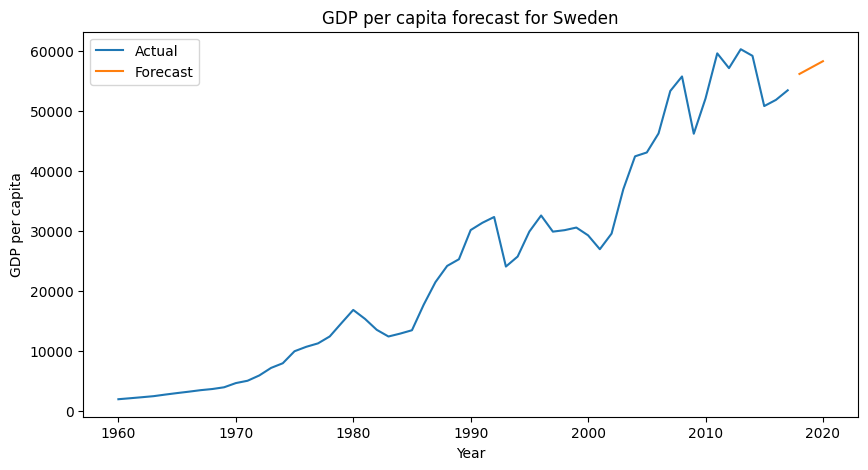

In [156]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(sweden_df["ds"], sweden_df["y"], label="Actual")
plt.plot(fcasts["ds"], fcasts["LinearRegression"], label="Forecast")

plt.title("GDP per capita forecast for Sweden")
plt.xlabel("Year")
plt.ylabel("GDP per capita")
plt.legend()
plt.show()

Normally, we test the model on a holdout set first. If it performs well, then we train on the whole dataset and forecast the future.

# 5.2 some simple forecasting methods

## Average method

The forecasts of all future values are equal to the average (or “mean”) of the historical data.

In [157]:
production_df = pd.read_csv("../data/tsibbledata/aus_production.csv")

production_df["ds"] = pd.PeriodIndex(
    production_df["Quarter"].str.replace(" ", "", regex=False),
    freq="Q"
).to_timestamp()

bricks_df = (
    production_df
    .assign(
        unique_id="Bricks",
        y=production_df["Bricks"]
    )
    .loc[lambda x: x["ds"].between("1970-01-01", "2004-12-31")]
    [["unique_id", "ds", "y"]]
    .dropna()
)

bricks_df

,unique_id,ds,y
56,Bricks,1970-01-01,386.0
57,Bricks,1970-04-01,428.0
58,Bricks,1970-07-01,434.0
59,Bricks,1970-10-01,417.0
60,Bricks,1971-01-01,385.0
...,...,...,...
191,Bricks,2003-10-01,413.0
192,Bricks,2004-01-01,409.0
193,Bricks,2004-04-01,423.0
194,Bricks,2004-07-01,428.0


In [158]:
from statsforecast.models import HistoricAverage

avg_method = HistoricAverage()

sf = StatsForecast(models=[avg_method], freq="QS")

sf.fit(bricks_df)

forecasts = sf.predict(h=20)

forecasts.head()

,unique_id,ds,HistoricAverage
0,Bricks,2005-01-01,450.878571
1,Bricks,2005-04-01,450.878571
2,Bricks,2005-07-01,450.878571
3,Bricks,2005-10-01,450.878571
4,Bricks,2006-01-01,450.878571


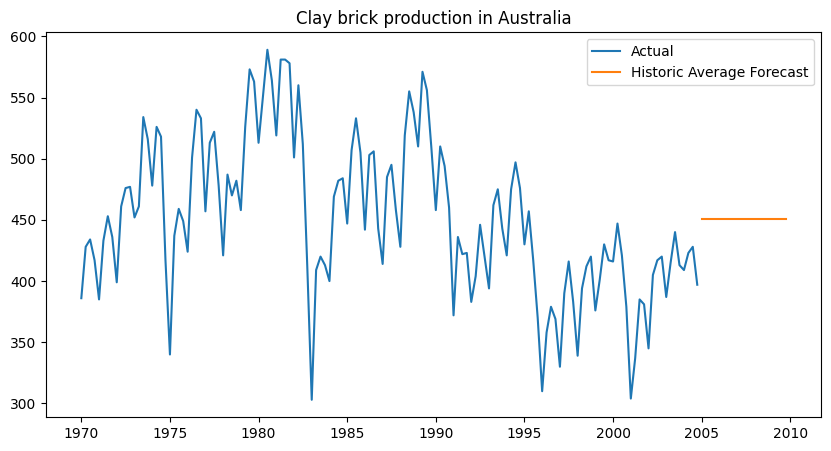

In [159]:
fig, ax = plt.subplots(figsize=(10, 5))

# Actual data
ax.plot(
    bricks_df["ds"],
    bricks_df["y"],
    label="Actual"
)

# Forecasts
ax.plot(
    forecasts["ds"],
    forecasts["HistoricAverage"],
    label="Historic Average Forecast"
)

ax.legend()
ax.set_title("Clay brick production in Australia")
plt.show()

## Naïve method



For naïve forecasts, we simply set all forecasts to be the value of the last observation

## Seasonal naïve method

A similar method is useful for highly seasonal data. In this case, we set each forecast to be equal to the last observed value from the same season 

## Drift method

A variation on the Naïve method is to allow the forecasts to increase or decrease over time, where the amount of change over time (called the drift) is set to be the average change seen in the historical data.

## Example: Australian quarterly beer production

In [160]:
beers_df = (
    production_df[["ds", "Beer"]]
    .rename(columns={"Beer": "y"})
    .assign(unique_id="Beer")
    [["unique_id", "ds", "y"]]
    .dropna()
)

beers_df["ds"] = pd.to_datetime(beers_df["ds"])

beers_df

,unique_id,ds,y
0,Beer,1956-01-01,284
1,Beer,1956-04-01,213
2,Beer,1956-07-01,227
3,Beer,1956-10-01,308
4,Beer,1957-01-01,262
...,...,...,...
213,Beer,2009-04-01,398
214,Beer,2009-07-01,419
215,Beer,2009-10-01,488
216,Beer,2010-01-01,414


In [181]:
from statsforecast.models import HistoricAverage, Naive, SeasonalNaive, RandomWalkWithDrift



train = beers_df.loc[lambda x: (x["ds"] >= "1992-01-01") & (x["ds"] < "2007-01-01")]
test = beers_df.loc[lambda x: x["ds"] >= "2007-01-01"]

avg_method = HistoricAverage()
naive_method = Naive()
seasonal_naive_method = SeasonalNaive(season_length=4)
drift_method = RandomWalkWithDrift()

sf = StatsForecast(
    models=[avg_method, naive_method, seasonal_naive_method, drift_method],
    freq="QS"
)

sf.fit(train)

fcasts = sf.predict(h=len(test))
fcasts = fcasts.assign(y=test["y"].to_numpy())

In [182]:
fcasts

,unique_id,ds,HistoricAverage,Naive,SeasonalNaive,RWD,y
0,Beer,2007-01-01,436.450012,491.0,438.0,491.813568,427
1,Beer,2007-04-01,436.450012,491.0,386.0,492.627106,383
2,Beer,2007-07-01,436.450012,491.0,405.0,493.440674,394
3,Beer,2007-10-01,436.450012,491.0,491.0,494.254242,473
4,Beer,2008-01-01,436.450012,491.0,438.0,495.067810,420
5,Beer,2008-04-01,436.450012,491.0,386.0,495.881348,390
6,Beer,2008-07-01,436.450012,491.0,405.0,496.694916,410
7,Beer,2008-10-01,436.450012,491.0,491.0,497.508484,488
8,Beer,2009-01-01,436.450012,491.0,438.0,498.322021,415
9,Beer,2009-04-01,436.450012,491.0,386.0,499.135590,398


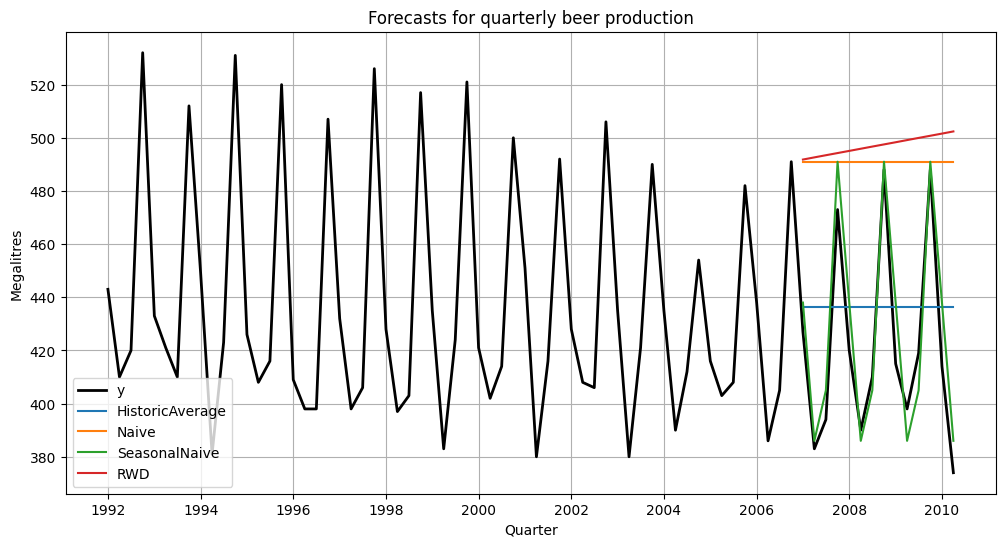

In [183]:
actual_all = pd.concat([train, test])

plt.figure(figsize=(12, 6))

plt.plot(actual_all["ds"], actual_all["y"], label="y", color="black", linewidth=2)

plt.plot(fcasts["ds"], fcasts["HistoricAverage"], label="HistoricAverage")
plt.plot(fcasts["ds"], fcasts["Naive"], label="Naive")
plt.plot(fcasts["ds"], fcasts["SeasonalNaive"], label="SeasonalNaive")
plt.plot(fcasts["ds"], fcasts["RWD"], label="RWD")
plt.title("Forecasts for quarterly beer production")
plt.xlabel("Quarter")
plt.ylabel("Megalitres")
plt.legend()
plt.grid(True)
plt.show()

## Example: Google’s daily closing stock price

In [164]:
goog_df = (
    pd.read_csv("../data/tsibbledata/gafa_stock.csv", parse_dates=["Date"])
    .loc[lambda x: (x["Symbol"] == "GOOG") & x["Date"].between("2015-01-01", "2016-01-31")]
    .rename(columns={"Date": "ds", "Close": "y"})
    .assign(unique_id="GOOG_Close")
    [["unique_id", "ds", "y"]]
)

In [165]:
import numpy as np
from statsforecast.models import RandomWalkWithDrift

train = goog_df.loc[lambda x: x["ds"].dt.year == 2015].copy()
test = goog_df.loc[lambda x: x["ds"].dt.year == 2016].copy()

train["ds"] = np.arange(len(train))
test["ds"] = len(train) + np.arange(len(test))

avg_method = HistoricAverage()
naive_method = Naive()
drift_method = RandomWalkWithDrift()

sf = StatsForecast(
    freq=1,
    models=[drift_method, avg_method, naive_method]
)

sf.fit(train)

fcasts = sf.predict(h=len(test)).assign(y=test["y"].to_numpy())

fcasts.head()

,unique_id,ds,RWD,HistoricAverage,Naive,y
0,GOOG_Close,252,759.823998,601.550547,758.880005,741.840027
1,GOOG_Close,253,760.767991,601.550547,758.880005,742.580017
2,GOOG_Close,254,761.711984,601.550547,758.880005,743.619995
3,GOOG_Close,255,762.655977,601.550547,758.880005,726.390015
4,GOOG_Close,256,763.599970,601.550547,758.880005,714.469971


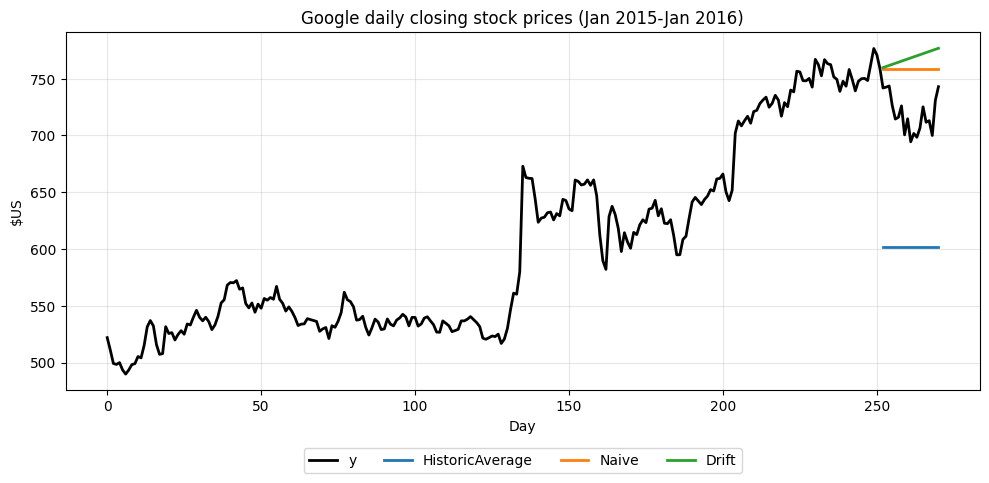

In [166]:
import matplotlib.pyplot as plt
import pandas as pd

# Combine train and test actuals
actuals = pd.concat([train, test])

plt.figure(figsize=(10, 5))

# Actual values (black line)
plt.plot(
    actuals["ds"],
    actuals["y"],
    color="black",
    linewidth=2,
    label="y"
)

# Forecasts
plt.plot(
    fcasts["ds"],
    fcasts["HistoricAverage"],
    label="HistoricAverage",
    linewidth=2
)

plt.plot(
    fcasts["ds"],
    fcasts["Naive"],
    label="Naive",
    linewidth=2
)

plt.plot(
    fcasts["ds"],
    fcasts["RWD"],
    label="Drift",
    linewidth=2
)

plt.title("Google daily closing stock prices (Jan 2015-Jan 2016)")
plt.xlabel("Day")
plt.ylabel("$US")
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=4)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5.3 Fitted values and residuals

a forecasting model produces fitted values. the difference between actual values and fitted values is called residual. Residuals are used to evalute whether a model has adequetly captured the patterns in the data.

fitted values are the predictions generated by the model for the training data -  the values are forecasted on the test data are called forecasts

In [167]:
beers_df = beers_df.loc[
    lambda x: (x["unique_id"] == "Beer") & (x["ds"] >= "1992")
]

train = beers_df.loc[lambda x: x["ds"] < "2007"]
test = beers_df.loc[lambda x: x["ds"] >= "2007"]

avg_method = HistoricAverage()
sf = StatsForecast(models=[avg_method], freq="QS")
sf.forecast(h=14, df=train, fitted=True)
fitted_values = sf.forecast_fitted_values()
df = train.assign(
    fitted=fitted_values["HistoricAverage"].to_numpy(),
    resid=lambda x: x["y"] - x["fitted"],
    innov=lambda x: x["y"] - x["fitted"],
)

df.head()

,unique_id,ds,y,fitted,resid,innov
144,Beer,1992-01-01,443,436.450012,6.549988,6.549988
145,Beer,1992-04-01,410,436.450012,-26.450012,-26.450012
146,Beer,1992-07-01,420,436.450012,-16.450012,-16.450012
147,Beer,1992-10-01,532,436.450012,95.549988,95.549988
148,Beer,1993-01-01,433,436.450012,-3.450012,-3.450012


# 5.4 Residuals diagnotistics

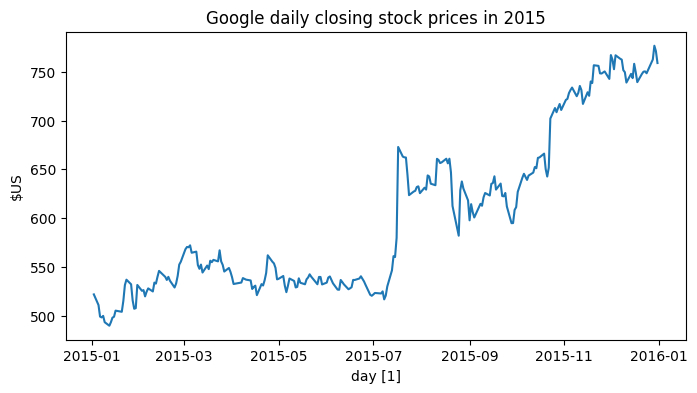

In [168]:
train_goog = goog_df.loc[lambda x: x["ds"].dt.year == 2015]

plt.figure(figsize=(8,4))
plt.plot(train_goog["ds"], train_goog["y"])
plt.title("Google daily closing stock prices in 2015")
plt.ylabel("$US")
plt.xlabel("day [1]")
plt.show()

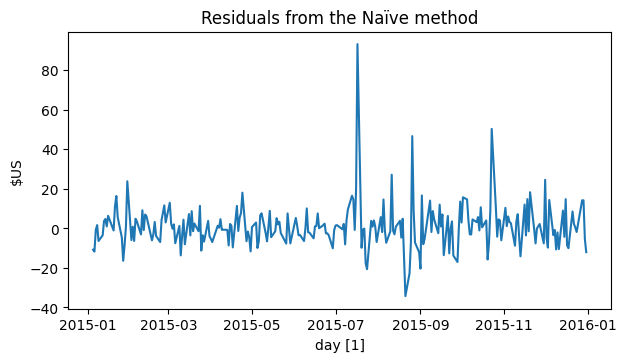

In [169]:
plt.rcParams["figure.figsize"] = (7, 3.6)

resid = train_goog.assign(resid=lambda x: x["y"].diff())

plt.figure()
plt.plot(resid["ds"], resid["resid"])

plt.title("Residuals from the Naïve method")
plt.xlabel("day [1]")
plt.ylabel("$US")

plt.show()

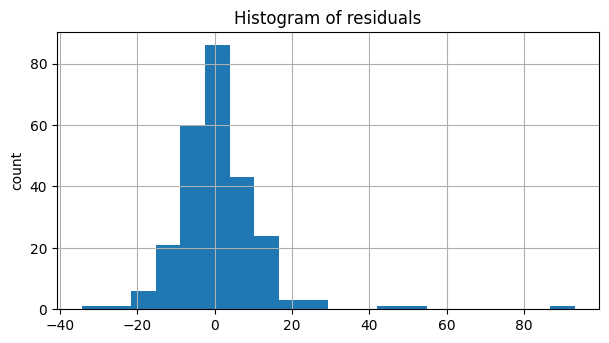

In [170]:
ax = resid["resid"].hist(bins=20)
ax.set(title="Histogram of residuals", ylabel="count")
plt.show()

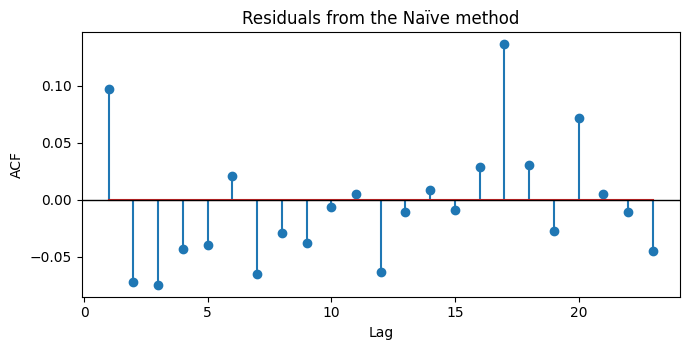

In [171]:
from statsmodels.tsa.stattools import acf

acf_vals = acf(
    resid["resid"].iloc[1:],
    fft=False
)

lags = np.arange(1, len(acf_vals))

plt.figure(figsize=(7, 3.6))
plt.stem(lags, acf_vals[1:])
plt.axhline(0, color="black", linewidth=1)

plt.title("Residuals from the Naïve method")
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.tight_layout()
plt.show()

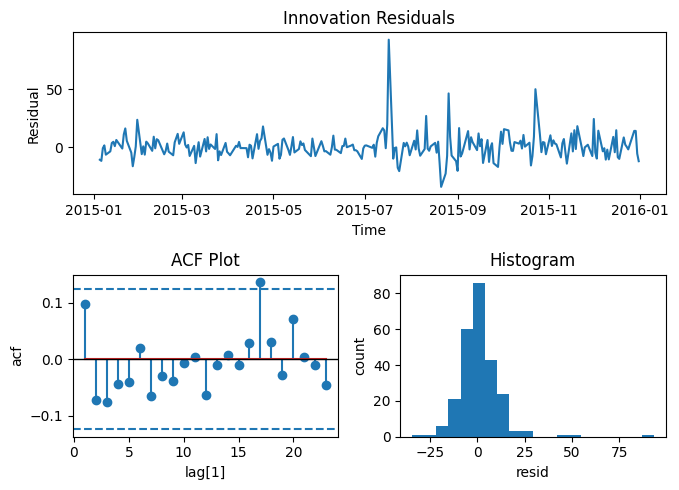

In [172]:
def plot_diagnostics(data):
    _, axes = plt.subplot_mosaic(
        [["resid", "resid"],
         ["acf", "hist"]],
        figsize=(7, 5)
    )

    # Residual plot
    ax = axes["resid"]
    ax.plot(data["ds"], data["resid"])
    ax.set_title("Innovation Residuals")
    ax.set_xlabel("Time")
    ax.set_ylabel("Residual")

    # ACF plot (without plot_acf)
    ax = axes["acf"]
    resid_clean = data["resid"].dropna()

    acf_vals = acf(resid_clean, fft=False)
    lags = np.arange(1, len(acf_vals))

    ax.stem(lags, acf_vals[1:])
    ax.axhline(0, color="black", linewidth=1)

    # Approximate 95% confidence bounds
    conf = 1.96 / np.sqrt(len(resid_clean))
    ax.axhline(conf, linestyle="--")
    ax.axhline(-conf, linestyle="--")

    ax.set_title("ACF Plot")
    ax.set_xlabel("lag[1]")
    ax.set_ylabel("acf")

    # Histogram
    ax = axes["hist"]
    ax.hist(resid_clean, bins=20)
    ax.set_title("Histogram")
    ax.set_xlabel("resid")
    ax.set_ylabel("count")

    plt.tight_layout()
    plt.show()

plot_diagnostics(resid)

## Portmanteau tests

In addition to looking at the ACF plot, we can also perform a more formal test for autocorrelation by considering a whole set of $r_k$ values as a group, rather than treating each one separately.

The Ljung--Box test statistic is

$$
Q^* = T(T+2)\sum_{k=1}^{\ell}(T-k)^{-1}r_k^2
$$

where:

- $T$ = number of observations
- $\ell$ = number of lags included in the test
- $r_k$ = sample autocorrelation at lag $k$

Large values of $Q^*$ indicate evidence of autocorrelation in the residuals.

In the following code, we show results for

$$
\ell \in [1, 10].
$$

In [173]:
from statsmodels.stats.diagnostic import acorr_ljungbox

resid_test = acorr_ljungbox(resid["resid"].dropna(), boxpierce=True)
resid_test

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,2.417335,0.119999,2.388671,0.122217
2,3.761022,0.152512,3.711114,0.156366
3,5.192966,0.158200,5.114758,0.163584
4,5.674577,0.224805,5.584948,0.232363
5,6.084444,0.298089,5.983475,0.307830
6,6.194822,0.401724,6.090363,0.413144
7,7.302747,0.398053,7.158875,0.412528
8,7.524630,0.481225,7.371988,0.497080
9,7.901719,0.544080,7.732682,0.561294
10,7.914143,0.637223,7.744517,0.653776


# 5.5 Distributional forecasts

In [174]:
train = goog_df.loc[lambda x: x["ds"].dt.year == 2015].copy()
train["ds"] = np.arange(len(train))
naive_method = Naive()
sf = StatsForecast(models=[naive_method], freq=1)
fcasts = sf.forecast(df=train, h=10, level=[80, 95])
fcasts

,unique_id,ds,Naive,Naive-lo-80,Naive-lo-95,Naive-hi-80,Naive-hi-95
0,GOOG_Close,252,758.880005,744.539977,736.948825,773.220033,780.811185
1,GOOG_Close,253,758.880005,738.600143,727.864632,779.159867,789.895378
2,GOOG_Close,254,758.880005,734.042348,720.894087,783.717662,796.865923
3,GOOG_Close,255,758.880005,730.199949,715.017645,787.560061,802.742365
4,GOOG_Close,256,758.880005,726.814728,709.840395,790.945282,807.919615
5,GOOG_Close,257,758.880005,723.754254,705.159804,794.005756,812.600206
6,GOOG_Close,258,758.880005,720.939857,700.855556,796.820153,816.904454
7,GOOG_Close,259,758.880005,718.320281,696.849260,799.439729,820.910750
8,GOOG_Close,260,758.880005,715.859921,693.086464,801.900089,824.673546
9,GOOG_Close,261,758.880005,713.532855,689.527524,804.227155,828.232486


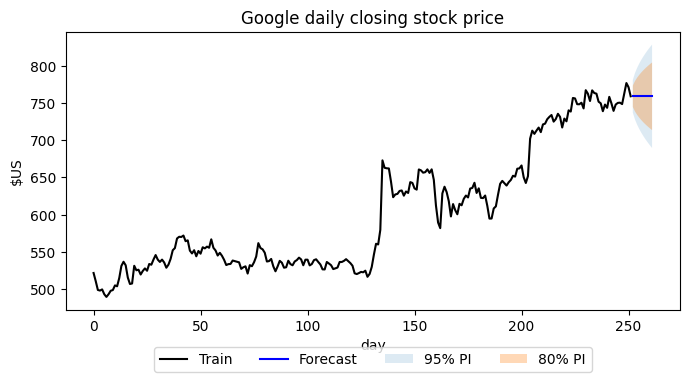

In [175]:
plt.rcParams["figure.figsize"] = (7, 4)
fig, ax = plt.subplots()
ax.plot(
    train["ds"],
    train["y"],
    color="black",
    label="Train"
)

ax.plot(
    fcasts["ds"],
    fcasts["Naive"],   # replace with your forecast column name
    color="blue",
    label="Forecast"
)
ax.fill_between(
    fcasts["ds"],
    fcasts["Naive-lo-95"],
    fcasts["Naive-hi-95"],
    alpha=0.15,
    label="95% PI"
)
ax.fill_between(
    fcasts["ds"],
    fcasts["Naive-lo-80"],
    fcasts["Naive-hi-80"],
    alpha=0.30,
    label="80% PI"
)

ax.set_xlabel("day")
ax.set_ylabel("$US")
ax.set_title("Google daily closing stock price")

ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=4)

plt.tight_layout()
plt.show()

# 5.6 Forecasting using transformations

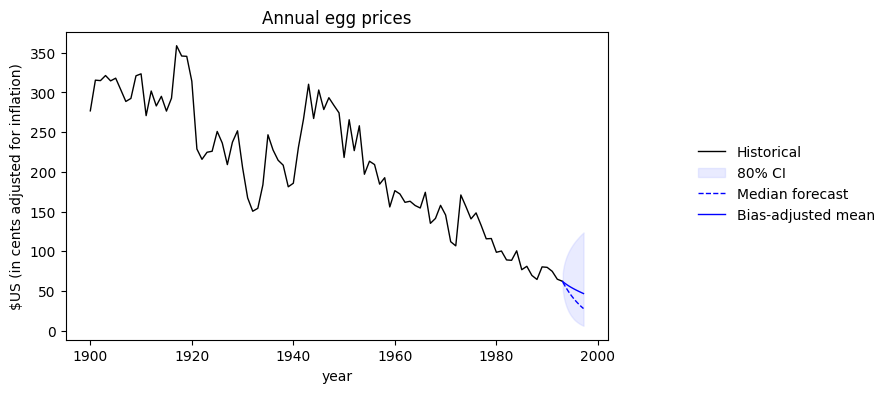

In [176]:
# Forecast on transformed series
egg_df = pd.read_csv("../data/fpp3/eggs.csv")
egg_df = egg_df.rename(columns={"DATE": "ds", "APU0000708111": "y"})
egg_df["ds"] = pd.to_datetime(egg_df["ds"])
egg_df["unique_id"] = "eggs"
egg_df = egg_df[["unique_id", "ds", "y"]]

egg_df_log = egg_df.assign(y=np.log(egg_df["y"]))
rwd_method = RandomWalkWithDrift()
sf = StatsForecast(models=[rwd_method], freq="MS")
sf.fit(egg_df_log)

# Find back-transformed values and apply bias correction
fcasts_log = sf.forecast(df=egg_df_log, h=50, level=[80, 95])
sigma_h = (fcasts_log["RWD-hi-80"] - fcasts_log["RWD-lo-80"]) / (2 * 1.28)
cols = ["RWD", "RWD-lo-80", "RWD-lo-95", "RWD-hi-80", "RWD-hi-95"]
fcasts = fcasts_log.assign(
    **{col: np.exp(fcasts_log[col]) for col in cols},
    **{"RWD-adjusted": np.exp(fcasts_log["RWD"]) * (1 + sigma_h**2 / 2)},
)

fig, ax = plt.subplots()
ax.plot(egg_df["ds"], egg_df["y"],
    color="black", label="Historical", linewidth=1)
ax.fill_between(fcasts["ds"], fcasts["RWD-lo-80"], fcasts["RWD-hi-80"],
    alpha=0.3, color="#B8BFFF", label="80% CI")
ax.plot(fcasts["ds"], fcasts["RWD"],
    color="blue", linestyle="--", label="Median forecast", linewidth=1)
ax.plot(fcasts["ds"], fcasts["RWD-adjusted"],
    color="blue", linestyle="-", label="Bias-adjusted mean", linewidth=1)
ax.set(
    title="Annual egg prices",
    xlabel="year",
    ylabel="$US (in cents adjusted for inflation)",
)
handles, labels = fig.axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=False, borderaxespad=0.0)
plt.show()

# 5.7 Forecasting with decomposition

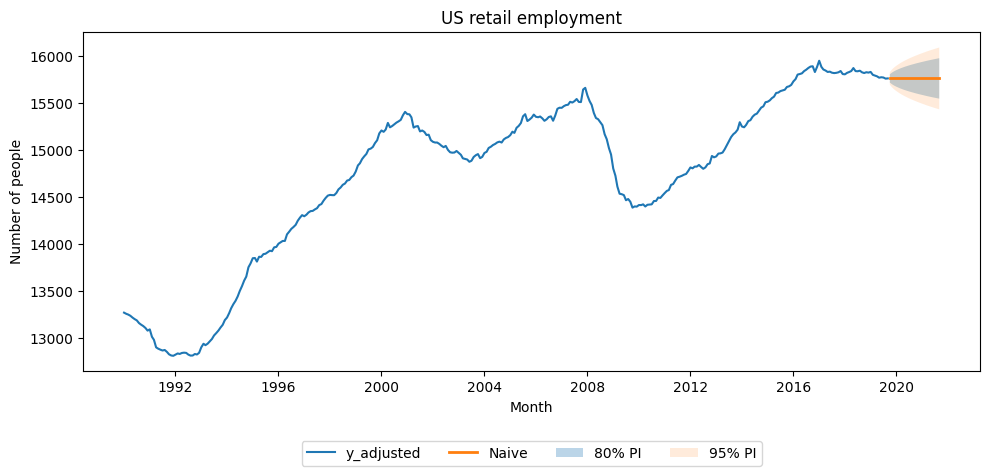

In [177]:
from statsmodels.tsa.seasonal import STL

us_retail_employment_df = (
    pd.read_csv("../data/fpp3/us_employment.csv")
    .assign(
        ds=lambda x: pd.to_datetime(x["Month"], format="%Y %b"),
        unique_id=lambda x: x["Title"],
        y=lambda x: x["Employed"]
    )
    .loc[lambda x:
        (x["unique_id"] == "Retail Trade") & (x["ds"] >= "1990")
    ]
    [["unique_id", "ds", "y"]]
)

stl = STL(us_retail_employment_df["y"].to_numpy(), period=12, robust=True)
res = stl.fit()

train_df = (
    us_retail_employment_df
    .assign(
        seasonal=res.seasonal,
        y_adjusted=lambda x: x["y"] - x["seasonal"],
    )
)

sf_train_df = train_df[["unique_id", "ds", "y_adjusted"]]

naive_method = Naive()
sf = StatsForecast(models=[naive_method], freq="ME")

adjusted_fcasts = sf.forecast(
    h=24,
    level=[80, 95],
    df=sf_train_df,
    target_col="y_adjusted",
    fitted=True
)

adjusted_fcasts_fitted = sf.forecast_fitted_values()


plt.figure(figsize=(10, 5))

plt.plot(
    train_df["ds"],
    train_df["y_adjusted"],
    label="y_adjusted",
    linewidth=1.5
)

plt.plot(
    adjusted_fcasts["ds"],
    adjusted_fcasts["Naive"],
    label="Naive",
    linewidth=2
)

plt.fill_between(
    adjusted_fcasts["ds"],
    adjusted_fcasts["Naive-lo-80"],
    adjusted_fcasts["Naive-hi-80"],
    alpha=0.3,
    label="80% PI"
)

plt.fill_between(
    adjusted_fcasts["ds"],
    adjusted_fcasts["Naive-lo-95"],
    adjusted_fcasts["Naive-hi-95"],
    alpha=0.15,
    label="95% PI"
)

plt.xlabel("Month")
plt.ylabel("Number of people")
plt.title("US retail employment")
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.3), ncol=4)

plt.tight_layout()
plt.show()

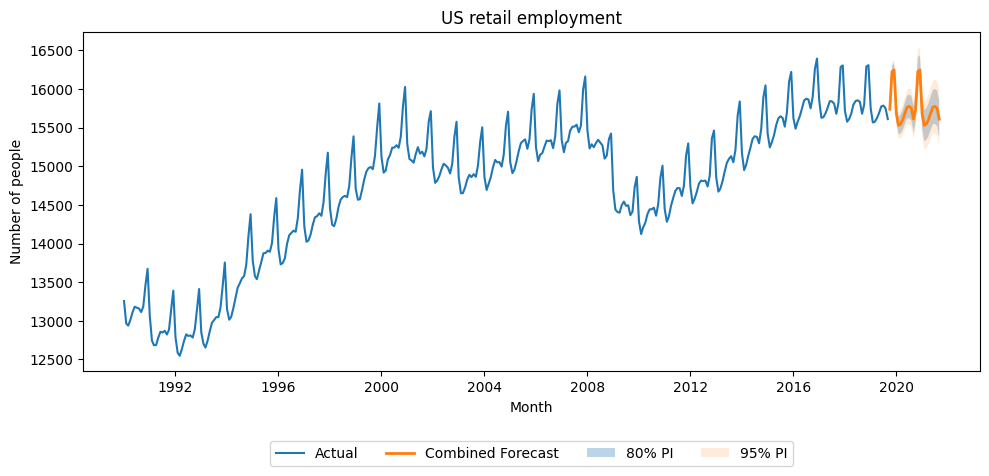

In [178]:
seasonal_naive = SeasonalNaive(12, alias="Seasonal")
sf = StatsForecast(models=[seasonal_naive], freq="ME")
seasonal_fcasts = sf.forecast(h=24, level=[80, 95], df=train_df,
    target_col="seasonal", fitted=True)

raw_fcasts = adjusted_fcasts.merge(seasonal_fcasts, on=["unique_id", "ds"])
fcasts = raw_fcasts.assign(**{
    "combined": lambda x: x["Naive"] + x["Seasonal"],
    "combined-lo-95": lambda x: x["Naive-lo-95"] + x["Seasonal-lo-95"],
    "combined-lo-80": lambda x: x["Naive-lo-80"] + x["Seasonal-lo-80"],
    "combined-hi-80": lambda x: x["Naive-hi-80"] + x["Seasonal-hi-80"],
    "combined-hi-95": lambda x: x["Naive-hi-95"] + x["Seasonal-hi-95"],
})

seasonal_fcasts_fitted = sf.forecast_fitted_values()
fitted = (
    adjusted_fcasts_fitted
    .merge(seasonal_fcasts_fitted, on=["unique_id", "ds"])
    .assign(combined=lambda x: x["Naive"] + x["Seasonal"])
    .merge(train_df, on=["unique_id", "ds"], how="right")
    .assign(resid=lambda x: x["y"] - x["combined"])
)

plt.figure(figsize=(10, 5))

# Historical data
plt.plot(
    train_df["ds"],
    train_df["y"],
    label="Actual",
    linewidth=1.5
)

# Forecast
plt.plot(
    fcasts["ds"],
    fcasts["combined"],
    label="Combined Forecast",
    linewidth=2
)

# 80% prediction interval
plt.fill_between(
    fcasts["ds"],
    fcasts["combined-lo-80"],
    fcasts["combined-hi-80"],
    alpha=0.3,
    label="80% PI"
)

# 95% prediction interval
plt.fill_between(
    fcasts["ds"],
    fcasts["combined-lo-95"],
    fcasts["combined-hi-95"],
    alpha=0.15,
    label="95% PI"
)

plt.xlabel("Month")
plt.ylabel("Number of people")
plt.title("US retail employment")

plt.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=4
)

plt.tight_layout()
plt.show()

# 5.8 Evaluationg point forecast accuracy

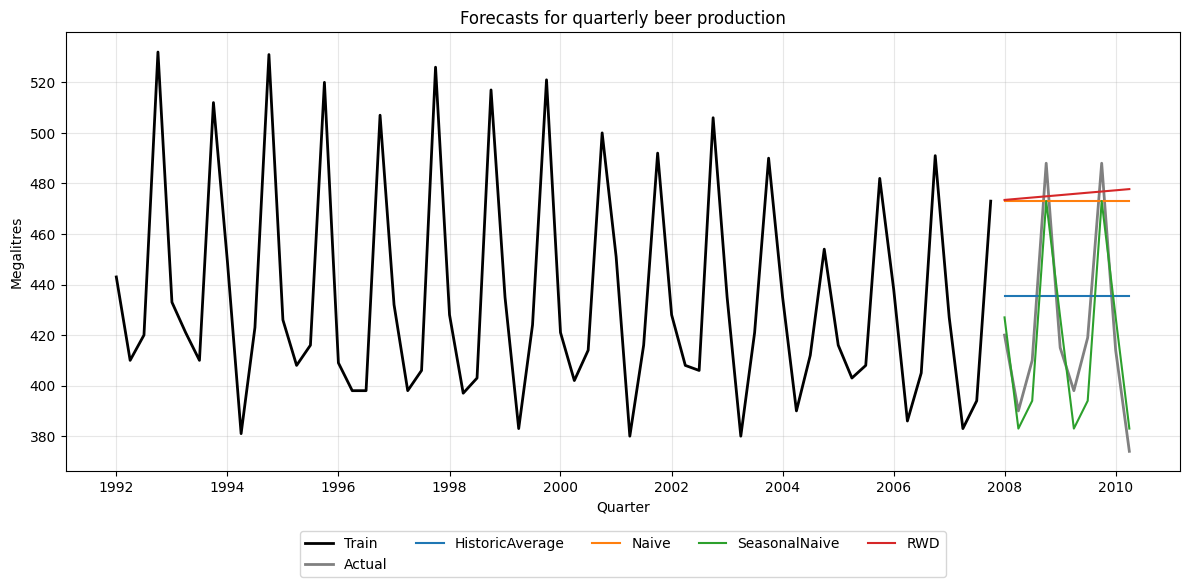

In [ ]:
train_df = beers_df.loc[lambda x: x["ds"].dt.year <= 2007]
test_df = beers_df.loc[lambda x: x["ds"].dt.year > 2007]

mean_method = HistoricAverage()
naive_method = Naive()
drift_method = RandomWalkWithDrift()
seasonal_naive = SeasonalNaive(4)

sf = StatsForecast(freq="QS", models=[drift_method, mean_method, naive_method, seasonal_naive])

preds = sf.forecast(df=train_df, h=10).assign(y=test_df["y"].to_numpy())

plt.figure(figsize=(12, 6))

plt.plot(train_df["ds"], train_df["y"], color="black", linewidth=2, label="Train")
plt.plot(preds["ds"], preds["y"], color="gray", linewidth=2, label="Actual")

plt.plot(preds["ds"], preds["HistoricAverage"], label="HistoricAverage")
plt.plot(preds["ds"], preds["Naive"], label="Naive")
plt.plot(preds["ds"], preds["SeasonalNaive"], label="SeasonalNaive")
plt.plot(preds["ds"], preds["RWD"], label="RWD")

plt.title("Forecasts for quarterly beer production")
plt.xlabel("Quarter")
plt.ylabel("Megalitres")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [203]:
from functools import partial
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from utilsforecast.evaluation import evaluate
from utilsforecast.feature_engineering import pipeline, trend
from utilsforecast.losses import rmse, mae, mape as _mape, mase, quantile_loss, mqloss
from statsforecast import StatsForecast
from statsforecast.models import (
    HistoricAverage,
    Naive,
    RandomWalkWithDrift,
    SeasonalNaive,
    SklearnModel,
)
from fpppy.models import LinearRegression

def mape(df, models, id_col = "unique_id", target_col = "y"):
    df_mape = _mape(df, models, id_col=id_col, target_col=target_col)
    df_mape.loc[:, df_mape.select_dtypes(include="number").columns] *= 100
    return df_mape

def quantile_score(df, models, q=0.5, id_col="unique_id", target_col="y"):
    df_qs = quantile_loss(df, models, q=q, id_col=id_col, target_col=target_col)
    df_qs.loc[:, df_qs.select_dtypes(include="number").columns] *= 2
    return df_qs

In [205]:
evaluation = evaluate(preds, train_df=train_df,
    metrics=[rmse, mae, mape, partial(mase, seasonality=4)])

labels = {
    "method": "Method",
    "rmse": "RMSE", "mae": "MAE",
    "mape": "MAPE", "mase": "MASE",
}
evaluation_transformed = (
    evaluation
    .drop(columns=["unique_id"]).set_index("metric")
    .rename_axis("", axis="rows").rename_axis("Method", axis="columns")
    .transpose().reset_index().rename(columns=labels)
)

evaluation_transformed

,Method,RMSE,MAE,MAPE,MASE
0,RWD,64.901294,58.876193,14.577488,4.117216
1,HistoricAverage,38.447245,34.825000,8.283390,2.435315
2,Naive,62.692902,57.400000,14.184424,4.013986
3,SeasonalNaive,14.310835,13.400000,3.168503,0.937063


# 5.9 Evaluating distributional forecast accuracy

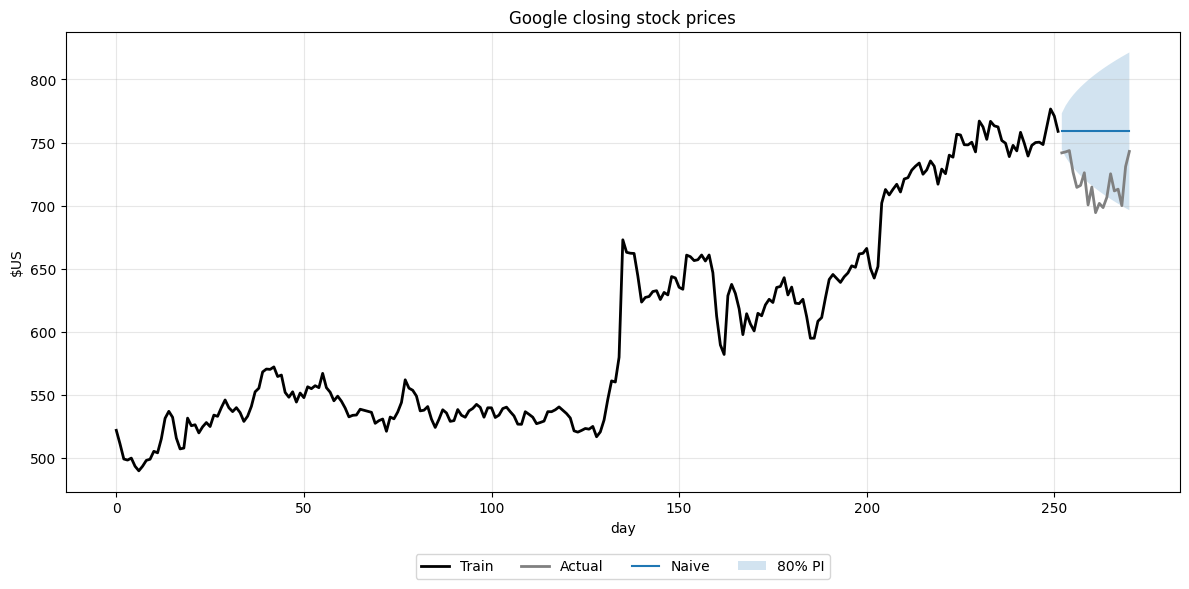

In [210]:
train_df = goog_df.loc[lambda x: x["ds"].dt.year == 2015].copy()
test_df = goog_df.loc[lambda x: x["ds"].dt.year == 2016].copy()

train_df["ds"] = np.arange(len(train_df))
test_df["ds"] = len(train_df) + np.arange(len(test_df))

naive_model = Naive()

sf = StatsForecast(models=[naive_model], freq=1)

preds = (
    sf.forecast(h=19, level=[80], df=train_df)
    .assign(y=test_df["y"].to_numpy())
)

plt.figure(figsize=(12, 6))

plt.plot(train_df["ds"], train_df["y"], color="black", linewidth=2, label="Train")
plt.plot(preds["ds"], preds["y"], color="gray", linewidth=2, label="Actual")
plt.plot(preds["ds"], preds["Naive"], label="Naive")

plt.fill_between(
    preds["ds"],
    preds["Naive-lo-80"],
    preds["Naive-hi-80"],
    alpha=0.2,
    label="80% PI"
)

plt.title("Google closing stock prices")
plt.xlabel("day")
plt.ylabel("$US")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [212]:
evaluation = evaluate(preds.iloc[[0]], metrics=[quantile_score], level=[80])
labels = {
    "method": "Method",
    "quantile_score_q0.1": "Quantile score (q=0.1)",
    "quantile_score_q0.9": "Quantile score (q=0.9)",
}
evaluation_transformed = (
    evaluation
    .drop(columns=["unique_id"]).set_index("metric")
    .rename_axis("", axis="rows").rename_axis("Method", axis="columns")
    .transpose().reset_index().rename(columns=labels)
)

evaluation_transformed

,Method,Quantile score (q=0.1),Quantile score (q=0.9)
0,Naive,4.85991,6.276001


In [213]:
def winkler_score(preds, model, alpha=0.2):
    pct = int(100 * (1 - alpha))
    lo = preds[f"{model}-lo-{pct}"]
    hi = preds[f"{model}-hi-{pct}"]
    y = preds["y"]
    return hi - lo + np.select(
        [(lo <= y) & (y <= hi), (y < lo), (y > hi)],
        [0, (2 / alpha) * (lo - y), (2 / alpha) * (y - hi)],
    )

winkler_score_df = pd.DataFrame({
    "Method": "Naive",
    "Winkler score": winkler_score(preds, "Naive"),
})
winkler_score_df.head(1)

,Method,Winkler score
0,Naive,55.679556


In [214]:
train_df = goog_df.loc[lambda x: x["ds"].dt.year == 2015].copy()
test_df = goog_df.loc[lambda x: x["ds"].dt.year == 2016].copy()
mean_method = HistoricAverage()
naive_method = Naive()
drift_method = RandomWalkWithDrift()
sf = StatsForecast(
    freq="B", models=[drift_method, naive_method, mean_method])

levels = list(np.arange(0, 100, 1 / 10))
preds = (
    sf.forecast(df=train_df, h=len(test_df), level=levels)
    .assign(y=test_df["y"].to_numpy())
)

models = ["RWD", "HistoricAverage", "Naive"]
raw_crps_df = evaluate(
    df=preds, models=models, metrics=[mqloss], level=levels)
crps_series = 2 * raw_crps_df[models].iloc[0].rename_axis("Method")
crps_df = crps_series.rename("CRPS").reset_index()
crps_df

/Users/omeraytug/Desktop/fpp3/.venv/lib/python3.13/site-packages/statsforecast/core.py:850: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fcsts_df[cols] = fcsts
/Users/omeraytug/Desktop/fpp3/.venv/lib/python3.13/site-packages/statsforecast/core.py:850: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fcsts_df[cols] = fcsts
/Users/omeraytug/Desktop/fpp3/.venv/lib/python3.13/site-packages/statsforecast/core.py:850: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, wh

,Method,CRPS
0,RWD,33.557082
1,HistoricAverage,76.788917
2,Naive,26.499780


In [215]:
naive_crps = crps_series.loc["Naive"]
crps_skill_df = crps_df.assign(
    skill_score=(naive_crps - crps_df["CRPS"]) / naive_crps)
crps_skill_df

,Method,CRPS,skill_score
0,RWD,33.557082,-0.266316
1,HistoricAverage,76.788917,-1.897719
2,Naive,26.499780,0.000000


# 5.10  Time series cross-validation

In [216]:
goog_2015 = goog_df.loc[lambda x: x["ds"].dt.year == 2015].copy()

drift_method = RandomWalkWithDrift()
sf = StatsForecast(models=[drift_method], freq="B")
cv_df = sf.cross_validation(h=1, df=goog_2015, step_size=1, test_size=249)
cv_df.head()

,unique_id,ds,cutoff,y,RWD
0,GOOG_Close,2015-01-07,2015-01-06,498.357513,487.850327
1,GOOG_Close,2015-01-08,2015-01-07,499.928864,490.497436
2,GOOG_Close,2015-01-09,2015-01-08,493.454498,494.426644
3,GOOG_Close,2015-01-12,2015-01-09,489.854309,487.757849
4,GOOG_Close,2015-01-13,2015-01-12,493.464447,484.507070
